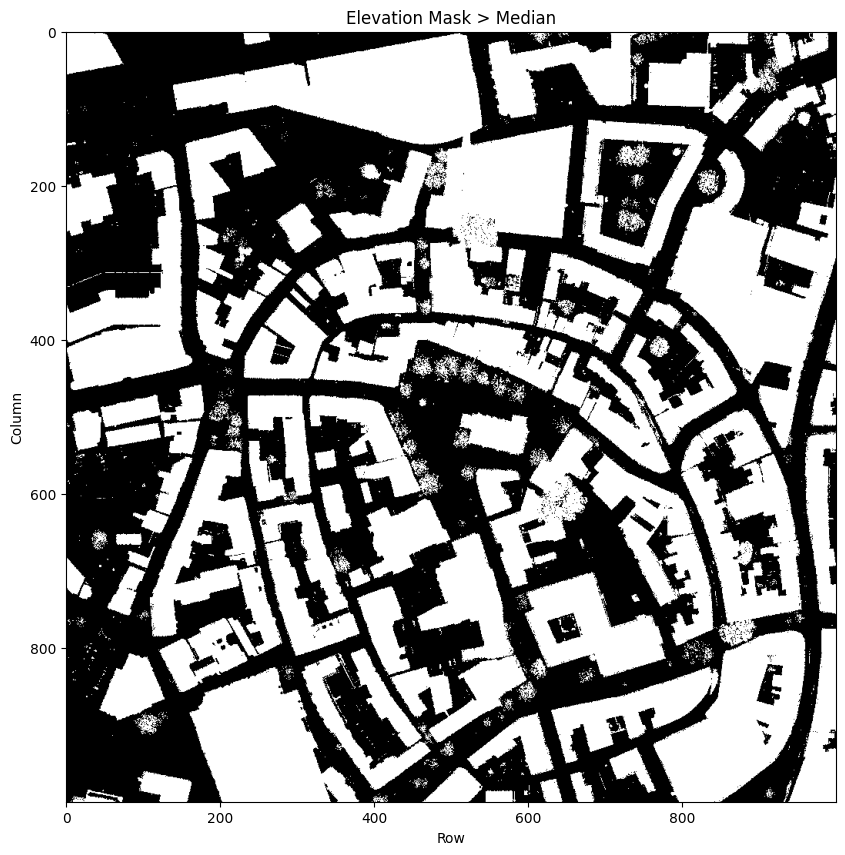

In [82]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Transformer

path = "R_34FN2.tif"
dataset = rasterio.open(path)
numpy_data = dataset.read(1)

lat = 52.220778
lon = 6.895444 

transformer_to_rd = Transformer.from_crs("EPSG:4326", "EPSG:28992", always_xy=True)
x_rd, y_rd = transformer_to_rd.transform(lon, lat)

row, col = dataset.index(x_rd, y_rd)

row_start = row - 500
row_end = row + 500
col_start = col - 500
col_end = col + 500

slice_data = numpy_data[row-500:row+500, col_s:col_end]

nodata = dataset.nodata
if nodata is not None:
    valid_pixels = slice_data[slice_data != nodata]
    median_height = np.median(valid_pixels)
else:
    median_height = np.median(slice_data)

mask = slice_data > median_height

# 9. Plot the data
plt.figure(figsize=(10, 10))
plt.imshow(mask, cmap="gray")
plt.title("Elevation Mask > Median")
plt.xlabel("Row")
plt.ylabel("Column")

plt.ticklabel_format(style='plain', useOffset=False, axis='both')
plt.show()

dataset.close()